# Câu 1: Health Insurance Cost Prediction

# 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD & INSPECT DATA

In [2]:
data = pd.read_csv("insurance_modified.csv")

In [3]:
print("--- Cấu trúc dữ liệu (data.info()) ---")
data.info()

--- Cấu trúc dữ liệu (data.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   smoker    1338 non-null   object 
 4   children  1232 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 73.3+ KB


In [4]:
print("\n--- 5 dòng đầu tiên của dữ liệu (data.head()) ---")
print(data.head())


--- 5 dòng đầu tiên của dữ liệu (data.head()) ---
   age     sex     bmi smoker        children     region      charges
0   19  female  27.900    yes         no kids  southwest  16884.92400
1   18    male  33.770     no          1 girl  southeast   1725.55230
2   28    male  33.000     no  three children  southeast   4449.46200
3   33    male  22.705     no         no kids  northwest  21984.47061
4   32    male  28.880     no             NaN  northwest   3866.85520


In [5]:
print("\n--- Thống kê mô tả (data.describe()) ---")
print(data.describe())


--- Thống kê mô tả (data.describe()) ---
               age          bmi       charges
count  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397  13270.422265
std      14.049960     6.098187  12110.011237
min      18.000000    15.960000   1121.873900
25%      27.000000    26.296250   4740.287150
50%      39.000000    30.400000   9382.033000
75%      51.000000    34.693750  16639.912515
max      64.000000    53.130000  63770.428010


In [6]:
# loại bỏ trùng lặp

print("\nKích thước tập dữ liệu trước khi xóa trùng lặp:", data.shape)
data = data.drop_duplicates().reset_index(drop=True)
print("Kích thước tập dữ liệu sau khi xóa trùng lặp:", data.shape)


Kích thước tập dữ liệu trước khi xóa trùng lặp: (1338, 7)
Kích thước tập dữ liệu sau khi xóa trùng lặp: (1337, 7)


In [7]:
# Missing value table
print("\n--- Missing Values Table ---")
missing_summary = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage (%)': (data.isnull().sum() / len(data)) * 100
})
print(missing_summary)


--- Missing Values Table ---
          Missing Values  Percentage (%)
age                    0        0.000000
sex                    0        0.000000
bmi                    0        0.000000
smoker                 0        0.000000
children             106        7.928197
region                 0        0.000000
charges                0        0.000000


***** Remark *****

- Overview: Data có 1,338 dòng và 7 cột. Sau khi kiểm tra, phát hiện và loại bỏ 1 dòng trùng lặp, kích thước tập dữ liệu còn lại là 1,337 dòng và 7 cột

- Missing Values: Biến charges và các biến demographic (age, sex, bmi, smoker, region) đều đầy đủ dữ liệu. Chỉ duy nhất cột children có 106 giá trị khuyết thiếu (chiếm 7.93%) cần được xử lý

- Data Quality: Cột children có định dạng text hỗn hợp (VD: no kids, 1 girl, three children...) và chứa giá trị NaN, cần phải chuẩn hóa về dạng số trước khi đưa vào mô hình

# 3. DATA CLEANING & PREPROCESSING

In [8]:
# Quan sát định dạng hỗn hợp của cột children trước khi xử lý

print("\nCác giá trị độc nhất trong cột 'children' ban đầu:")
print(data['children'].unique())

def clean_children_column(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().strip()
    
    # 1. Nếu không có con
    if 'no' in val or 'none' in val or '0' in val:
        return 0
    
    # 2. Nếu có ký tự nối con trai & con gái (Ví dụ: "1 boy & 1 girl", "1 boy & 2 girls")
    if '&' in val or 'and' in val:
        total = 0
        parts = val.replace('and', '&').split('&')
        for part in parts:
            for word, num in {'1':1, '2':2, '3':3, '4':4, '5':5, 'one':1, 'two':2, 'three':3, 'four':4, 'five':5}.items():
                if word in part:
                    total += num
                    break
        return total if total > 0 else 2
        
    # 3. Quét các trường hợp số thông thường lẻ từ lớn đến bé
    if 'five' in val or '5' in val: return 5
    if 'four' in val or '4' in val: return 4
    if 'three' in val or '3' in val: return 3
    if 'two' in val or '2' in val: return 2
    if 'one' in val or '1' in val or 'girl' in val or 'boy' in val or 'kid' in val or 'child' in val: return 1
    
    # 4. Ép kiểu số trực tiếp nếu là chuỗi số thuần túy
    try:
        return int(float(val))
    except:
        return np.nan

# Áp dụng chuẩn hóa vào cột dữ liệu
data['children_clean'] = data['children'].apply(clean_children_column)

# Điền missing value bằng Mode
children_mode = data['children_clean'].mode()[0]
data['children_clean'] = data['children_clean'].fillna(children_mode).astype(int)

# Ghi đè lại cột cũ
data = data.drop(columns=['children']).rename(columns={'children_clean': 'children'})

print("\n--- Phân phối giá trị cột 'children' sau khi sửa ---")
print(data['children'].value_counts())


Các giá trị độc nhất trong cột 'children' ban đầu:
['no kids' '1 girl' 'three children' nan 'none' '1 kid' '3 boys' '2 kids'
 '0' 'No children' '1 boy' 'one child' 'two children' '3 kids'
 '1 boy & 1 girl' '5 children' '2 boys & 1 girl' '2 boys' '1 child'
 '1 boy & 2 girls' '2 girls' 'four children' '2 boys & 3 girls' '4 kids'
 '4 boys & 1 girl' '2 boys & 2 girls' '1 boy & 3 girls' 'five kids'
 '3 boys & 1 girl' '3 boys & 2 girls' '1 boy & 4 girls']

--- Phân phối giá trị cột 'children' sau khi sửa ---
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


***** Remark *****

- Cleaning: Toàn bộ các chuỗi văn bản hỗn hợp ở cột children đã được bẻ tách logic và quy đổi thành công về dạng số nguyên thuần túy từ 0 đến 5 con

- Imputation: 106 giá trị thiếu (NaN) đã được điền đầy bằng giá trị yếu vị (Mode = 0, nhóm không có con chiếm đa số)

- Phân phối sau xử lý: Nhóm không có con chiếm tỷ lệ cao nhất (573 dòng), nhóm có 5 con là thấp nhất (18 dòng). Dữ liệu đã sẵn sàng để phân tích

# 4. VISUALIZATION

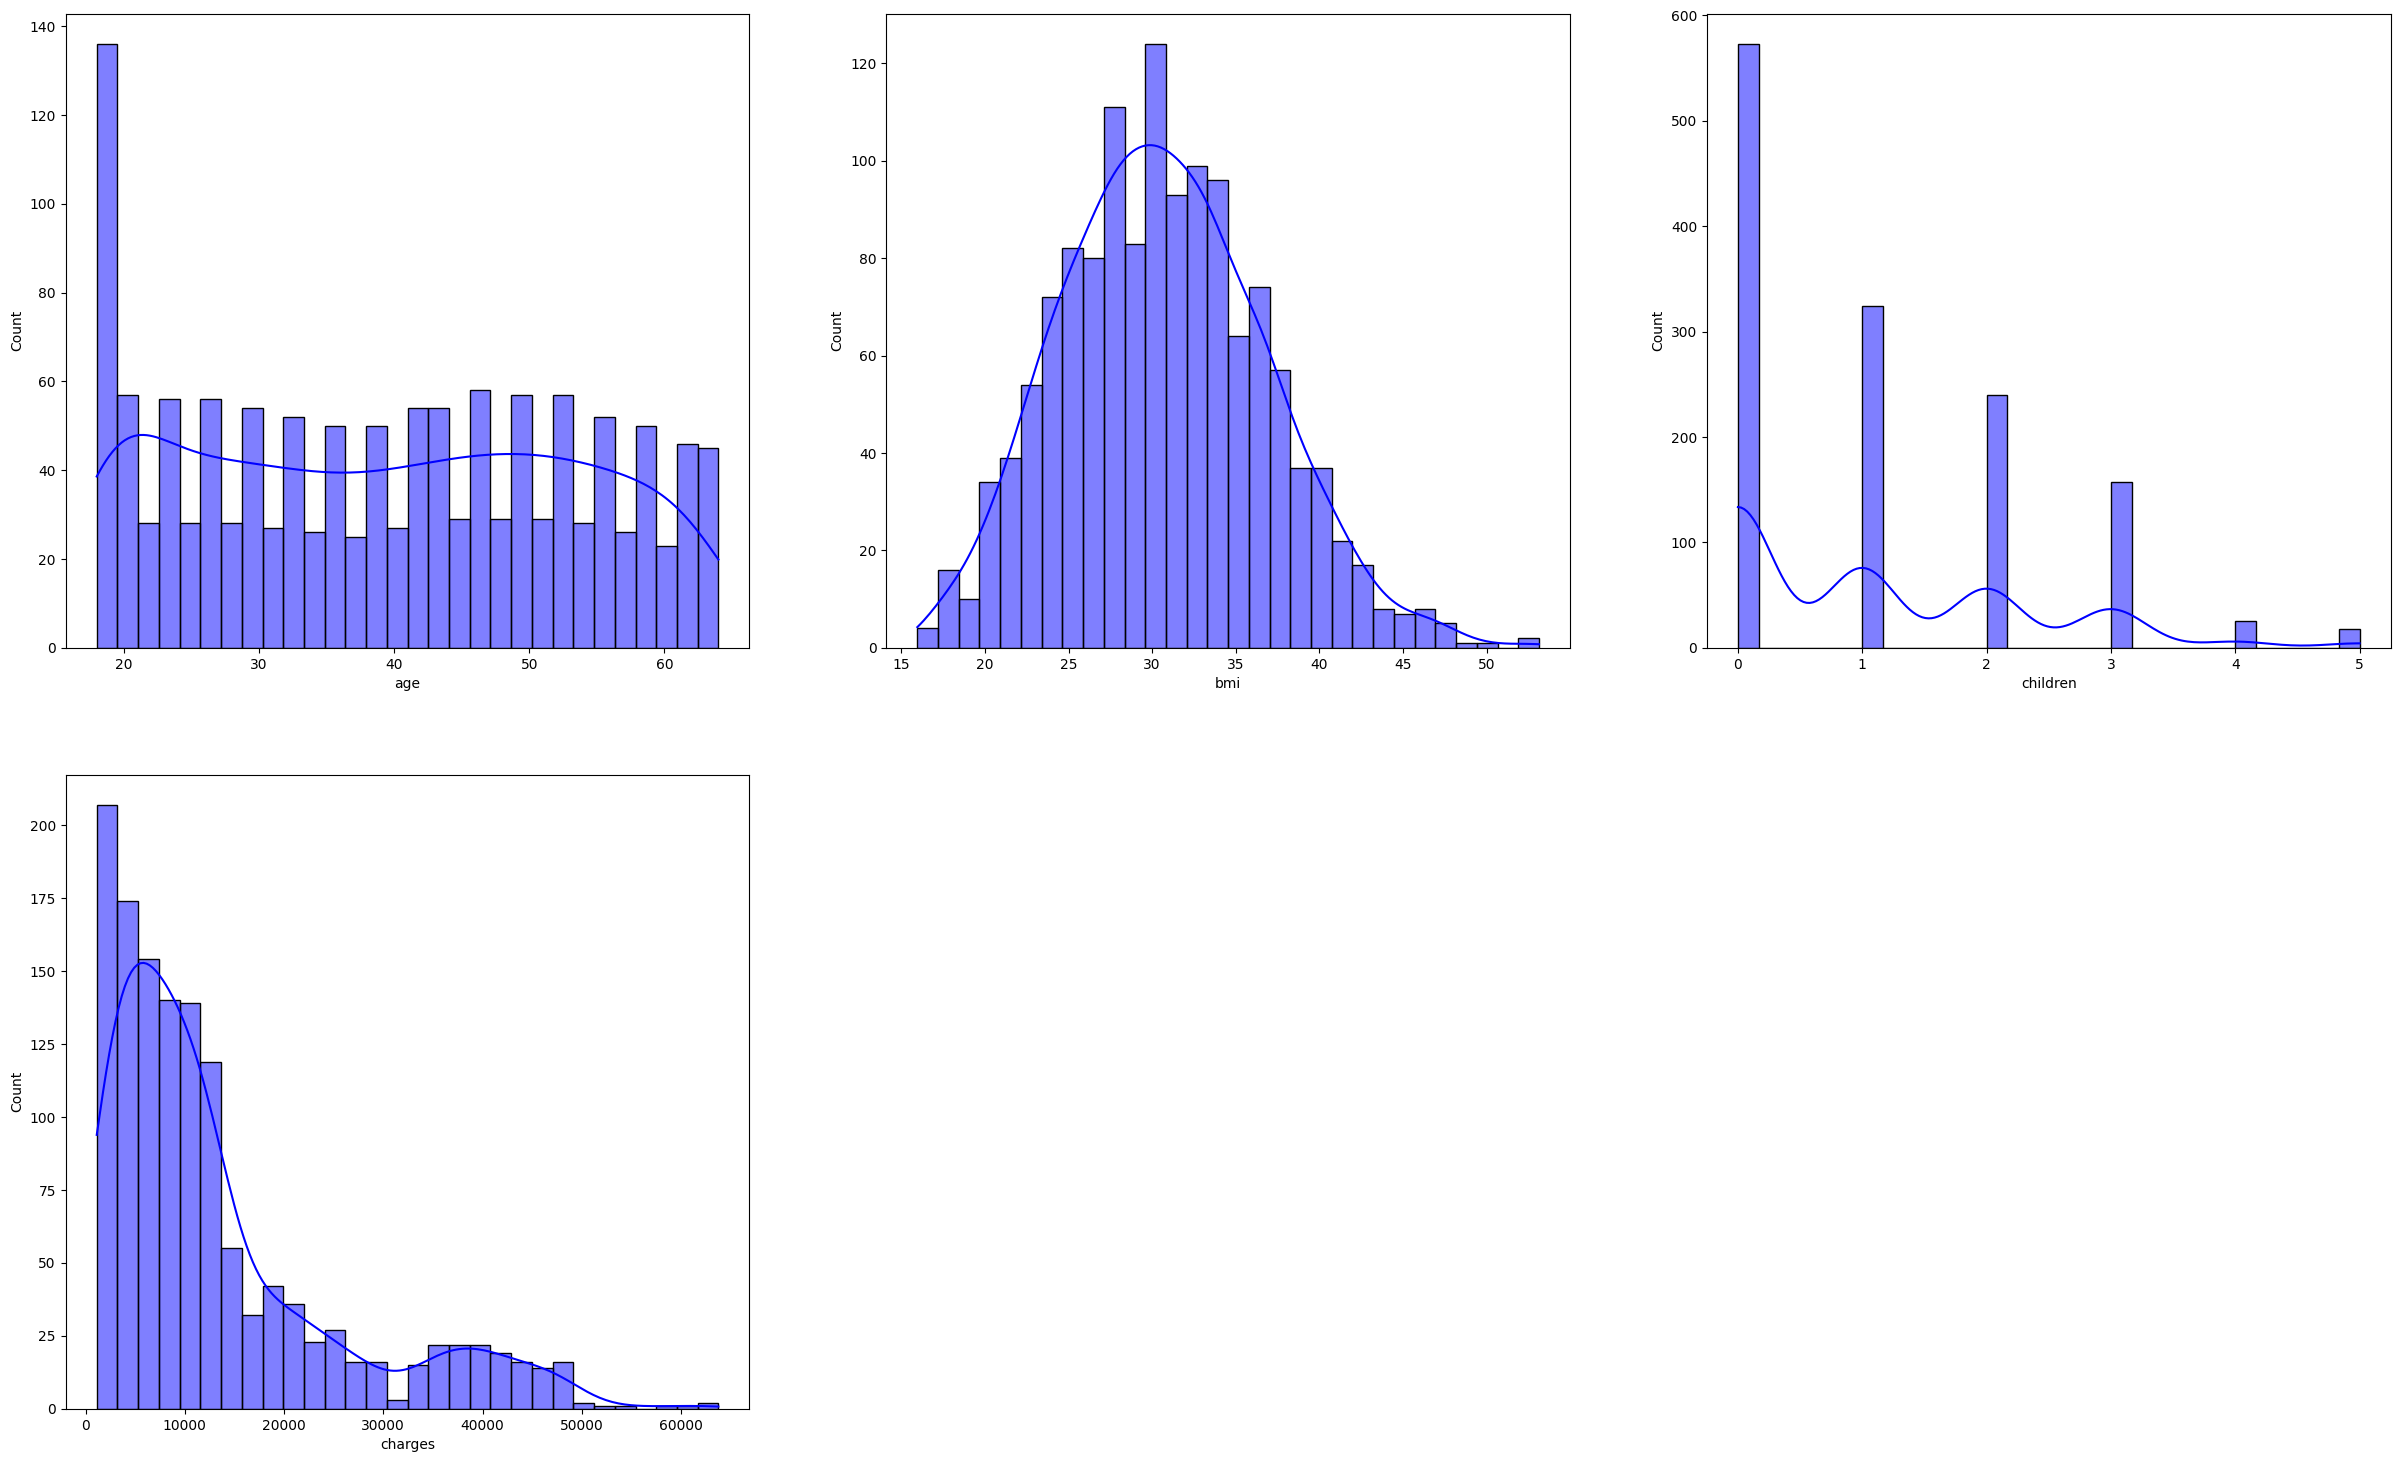

In [9]:
# Phân phối của Age, BMI, Children và Charges
plt.figure(figsize=(30,28))
for i, col in enumerate( ['age','bmi','children','charges']):
    plt.subplot(3, 3, i+1)
    sns.histplot(data = data,
            x = col,
            kde = True,
            bins = 30,
            color = 'blue')

plt.show()

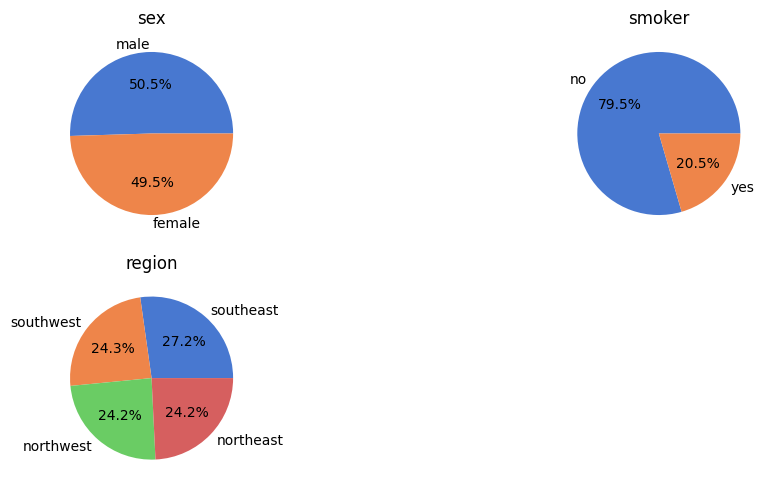

In [10]:
# Distribution of Sex, Smoker, and Region
plt.figure(figsize=(12,9))
for i,col in enumerate(['sex','smoker','region']):
    plt.subplot(3,2,i+1)
    x=data[col].value_counts().reset_index()
    plt.title(col)
    plt.pie(x=x['count'],labels=x[col],autopct="%0.1f%%",colors=sns.color_palette('muted'))

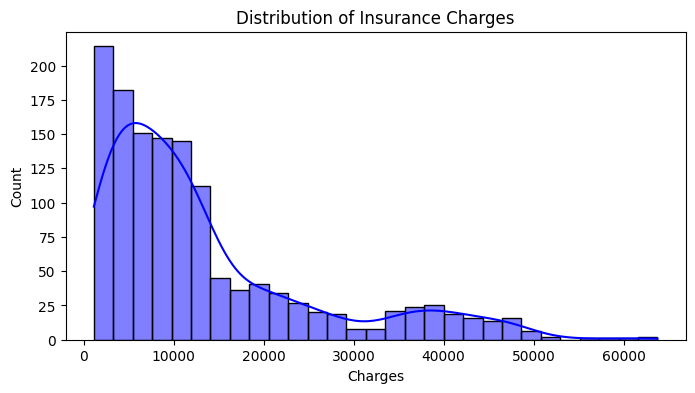

In [11]:
# Phân phối phí bảo hiểm (Histogram charges)
plt.figure(figsize=(8, 4))
sns.histplot(data['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.show()

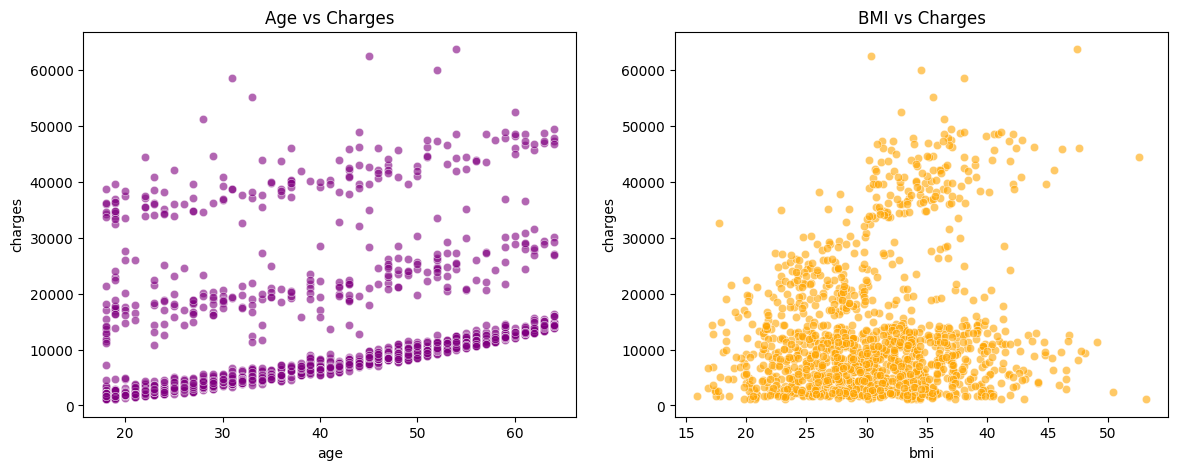

In [12]:
# Ảnh hưởng của Tuổi (age) và BMI đến phí bảo hiểm (Scatter Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=data, x='age', y='charges', alpha=0.6, ax=axes[0], color='purple')
axes[0].set_title('Age vs Charges')

sns.scatterplot(data=data, x='bmi', y='charges', alpha=0.6, ax=axes[1], color='orange')
axes[1].set_title('BMI vs Charges')
plt.show()

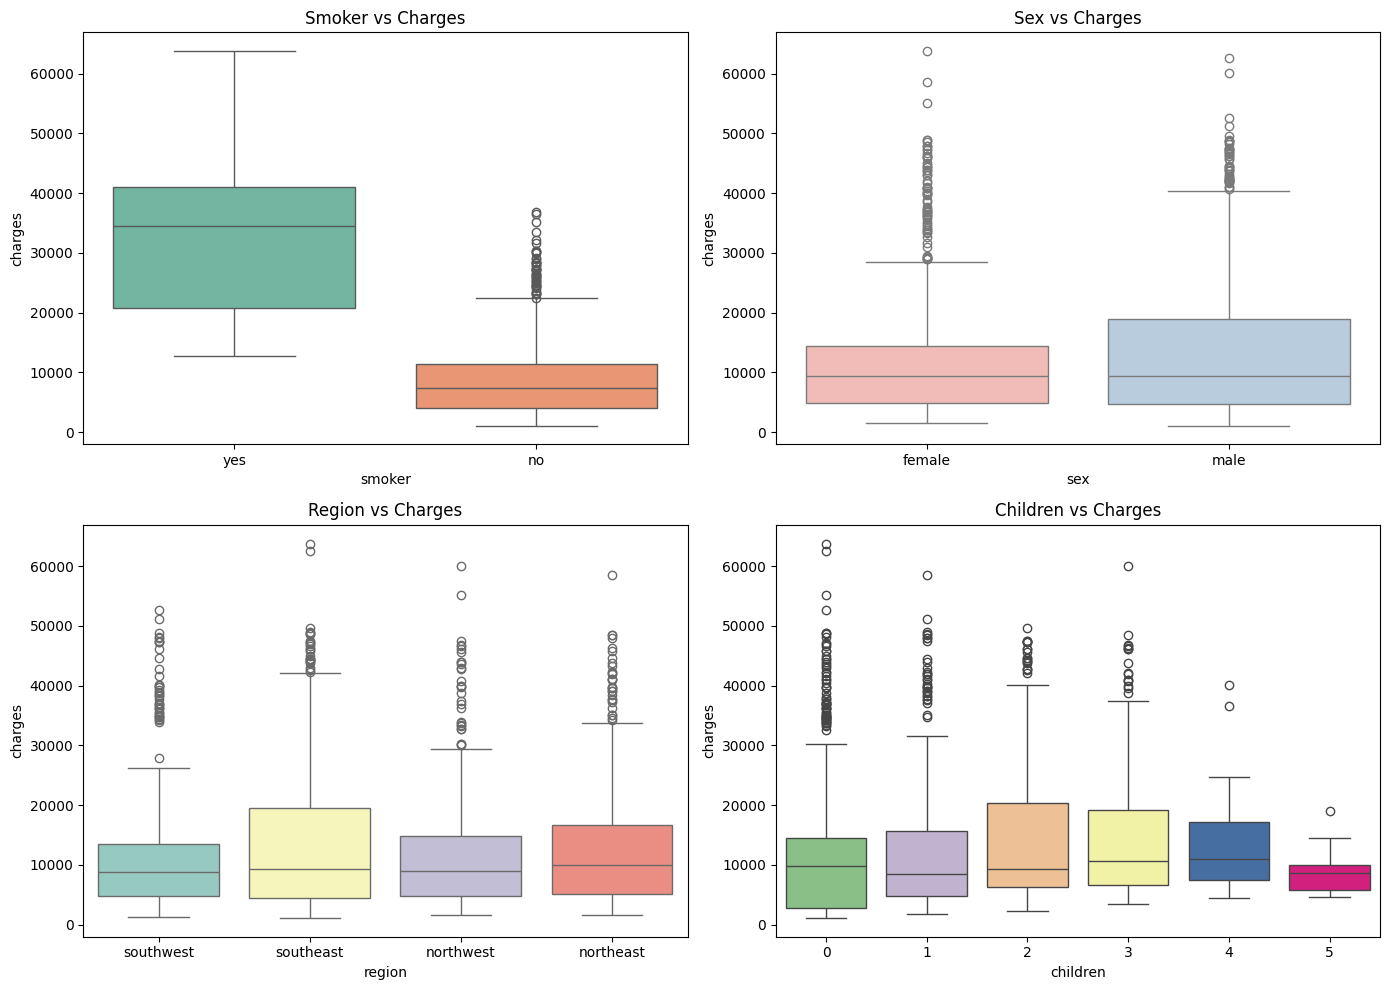

In [13]:
# So sánh các nhóm phân loại đối với Phí bảo hiểm (Boxplot)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=data, x='smoker', y='charges', ax=axes[0, 0], hue='smoker', palette='Set2', legend=False)
axes[0, 0].set_title('Smoker vs Charges')

sns.boxplot(data=data, x='sex', y='charges', ax=axes[0, 1], hue='sex', palette='Pastel1', legend=False)
axes[0, 1].set_title('Sex vs Charges')

sns.boxplot(data=data, x='region', y='charges', ax=axes[1, 0], hue='region', palette='Set3', legend=False)
axes[1, 0].set_title('Region vs Charges')

sns.boxplot(data=data, x='children', y='charges', ax=axes[1, 1], hue='children', palette='Accent', legend=False)
axes[1, 1].set_title('Children vs Charges')
plt.tight_layout()
plt.show()

Observation:

- charges (Phí bảo hiểm) có phân phối lệch phải mạnh (Right-skewed) với phần lớn khách hàng tập trung ở mức phí thấp ($2,000 - $12,000), xuất hiện một nhóm nhỏ chịu chi phí cực cao (Outliers) trên $40,000

- bmi có phân phối chuẩn (Normal distribution) tập trung quanh mức 30. age có phân phối đều ở các độ tuổi từ 18 đến 64

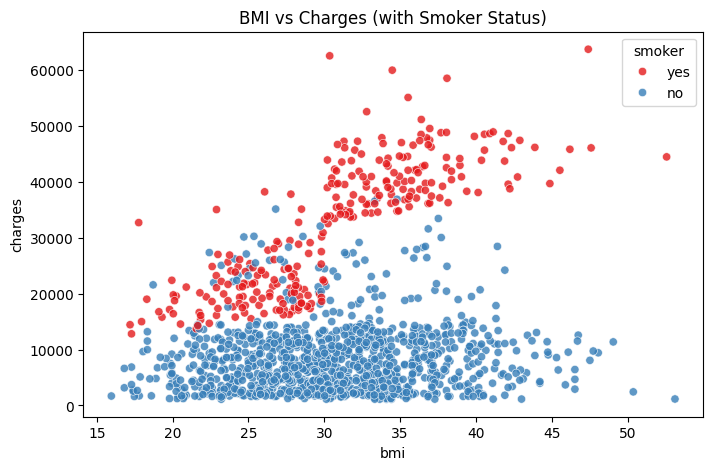

In [14]:
# Phối hợp giữa chỉ số BMI cao kết hợp hút thuốc (Scatter plot hue = smoker)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('BMI vs Charges (with Smoker Status)')
plt.show()

Observation:

- Yếu tố quyết định: Người hút thuốc (smoker = yes) chịu mức phí cao vượt trội ($30,000 - $45,000) so với người không hút thuốc ($2,000 - $12,000).

- Điểm bùng nổ rủi ro: Đối với người hút thuốc, khi chỉ số BMI vượt ngưỡng 30 (béo phì), chi phí bảo hiểm lập tức vọt thẳng lên mức rủi ro cao nhất hệ thống (trên $40,000). BMI cao ít ảnh hưởng đến chi phí của người không hút thuốc


In [15]:
# Mối quan hệ giữa các biến liên tục
print("\n--- Ma trận hệ số tương quan tuyến tính ---")
numerical_data = data.select_dtypes(include=np.number)
corr_matrix = numerical_data.dropna().corr()
print(corr_matrix)


--- Ma trận hệ số tương quan tuyến tính ---
               age       bmi   charges  children
age       1.000000  0.109344  0.298308  0.041536
bmi       0.109344  1.000000  0.198401  0.012755
charges   0.298308  0.198401  1.000000  0.067389
children  0.041536  0.012755  0.067389  1.000000


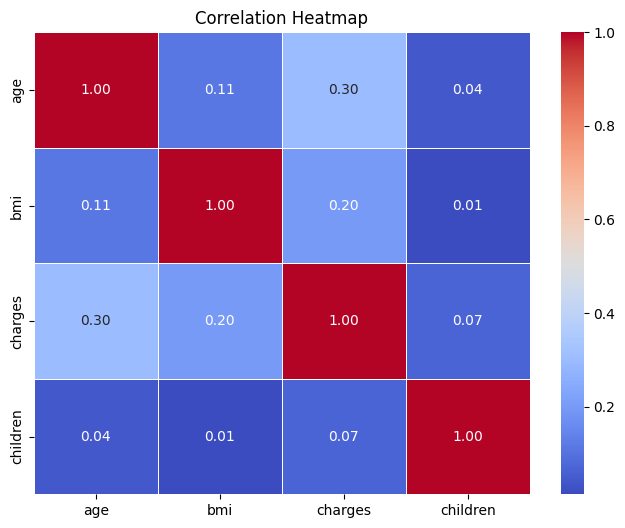

In [16]:
# Heatmap biểu diễn tương quan tuyến tính
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

Observation:

- Biến age (0.30) và bmi (0.20) có tương quan tuyến tính thuận vừa và nhẹ với charges

- Mối tương quan mạnh nhất với biến mục tiêu thuộc về biến định tính smoker (đã được chứng minh qua biểu đồ phân tán). Các biến số độc lập không có hiện tượng đa cộng tuyến mạnh với nhau

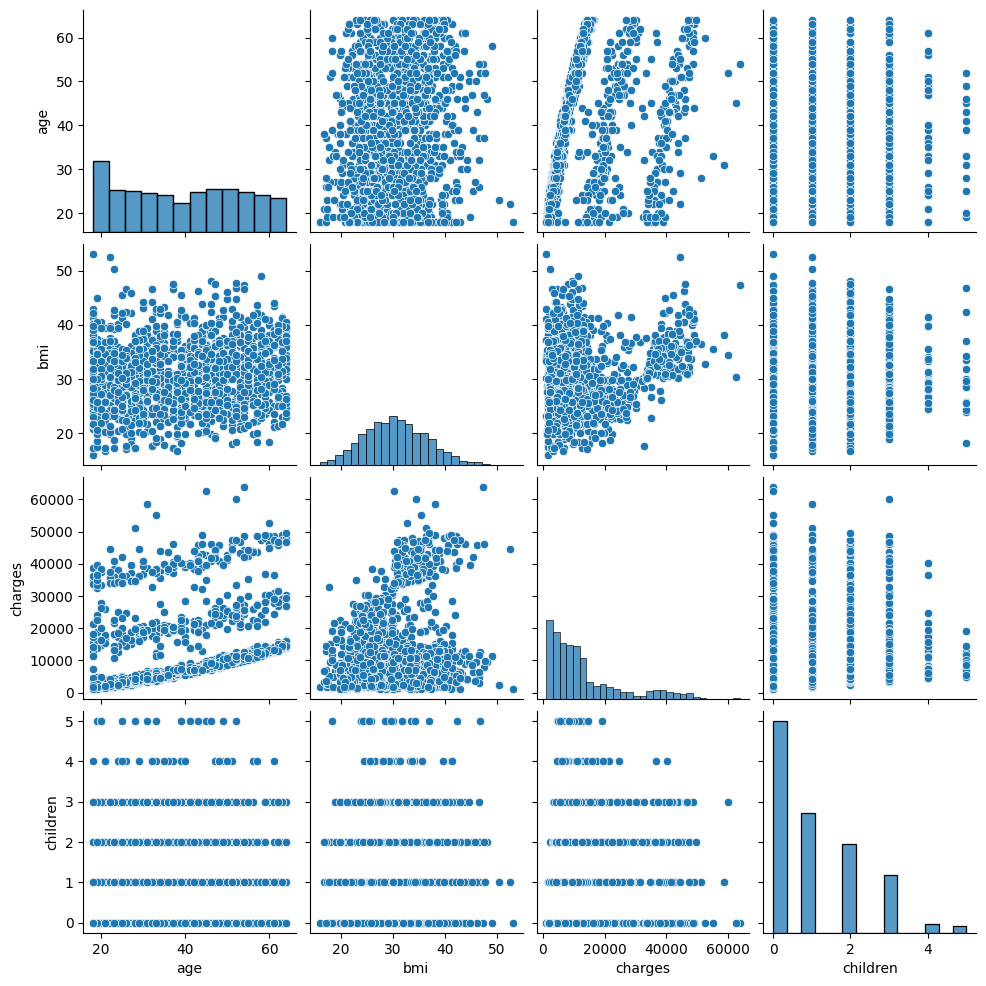

In [17]:
# Pairplot
sns.pairplot(data=data)
plt.show()

In [18]:
# Xuất tệp tin sạch phục vụ cho phần làm BigQuery ML tiếp theo
data.to_csv("insurance_cleaned.csv", index=False)
print("\n[ĐÃ LƯU]: Xuất tệp tin sạch 'insurance_cleaned.csv' thành công!")



[ĐÃ LƯU]: Xuất tệp tin sạch 'insurance_cleaned.csv' thành công!


# 5. VISUALIZATION

In [19]:
# Thêm các hàm đánh giá và chia dữ liệu từ thư viện sklearn vào Jupyter Lab
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Tách biến độc lập và biến mục tiêu
X = data.drop(columns=['charges'])
y = data['charges']

# Chia tập dữ liệu Train/Test tỉ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Thiết lập bộ tiền xử lý Encoding (One-Hot Encoding cho các cột Category)
categorical_features = ['sex', 'smoker', 'region']
categorical_transformer = OneHotEncoder(drop='first') # drop='first' để tránh bẫy đa cộng tuyến

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ], remainder='passthrough')

# Tạo Pipeline cho từng Model
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', LinearRegression())])

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', RandomForestRegressor(n_estimators=100, random_state=42))])

# Huấn luyện mô hình
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Dự đoán và Đánh giá
def evaluate_model(pipeline, X_test, y_test):
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate_model(lr_pipeline, X_test, y_test)
rf_mae, rf_rmse, rf_r2 = evaluate_model(rf_pipeline, X_test, y_test)

# Tạo bảng so sánh kết quả Python
performance_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R²': [lr_r2, rf_r2]
})

print("\n--- PYTHON MODELING EVALUATION ---")
print(performance_table.to_string(index=False))


--- PYTHON MODELING EVALUATION ---
                  Model         MAE        RMSE       R²
      Linear Regression 4177.045561 5956.342894 0.806929
Random Forest Regressor 2633.301296 4697.688540 0.879904


C:\Users\KIM\AppData\Local\Temp\ipykernel_54652\2368393684.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


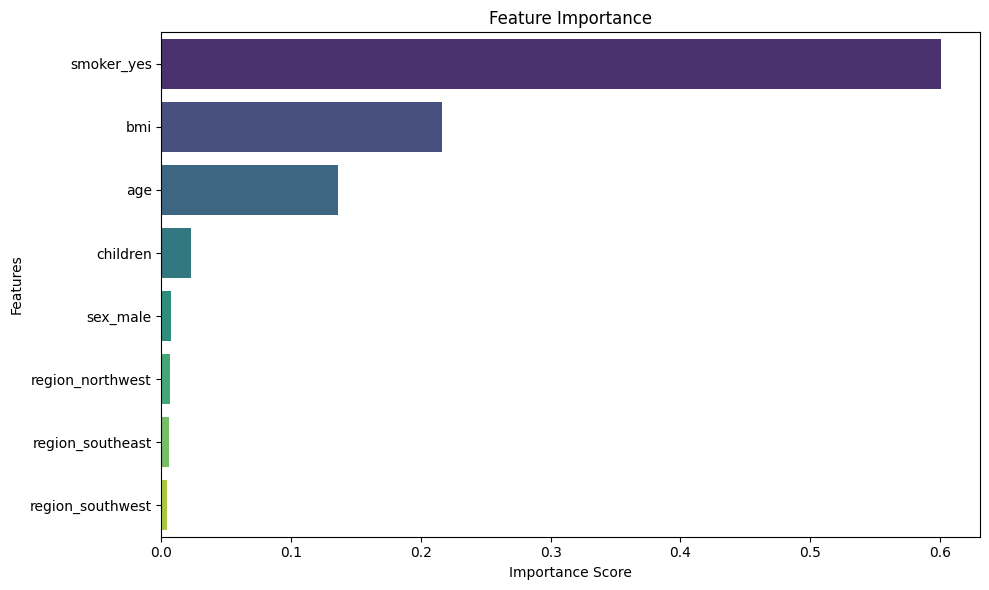

In [21]:
# Chart 1: Feature Importance

# 1. Trích xuất tên các cột sau khi đã qua bộ mã hóa OneHotEncoder
encoded_cat_features = rf_pipeline.named_steps['preprocessor']\
                                  .named_transformers_['cat']\
                                  .get_feature_names_out(categorical_features)
numeric_features = ['age', 'bmi', 'children']
all_features = list(encoded_cat_features) + numeric_features

# 2. Lấy giá trị tầm quan trọng từ mô hình Random Forest
importances = rf_pipeline.named_steps['model'].feature_importances_

# 3. Tạo DataFrame để dễ sắp xếp và vẽ đồ thị
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # Sắp xếp từ cao xuống thấp

# 4. Vẽ biểu đồ thanh ngang y hệt hình mẫu
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis'
)

plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

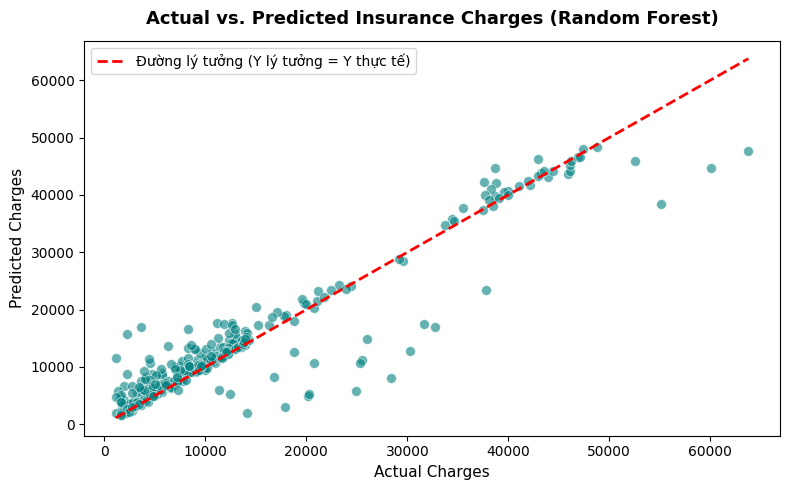

In [26]:
# Chart 2: Actual vs Predicted

%matplotlib inline

rf_preds = rf_pipeline.predict(X_test)

# Vẽ biểu đồ phân tán Actual vs Predicted
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.6, color='teal', edgecolor='w', s=50)

# Vẽ đường thẳng lý tưởng (Đường chéo 45 độ)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Đường lý tưởng (Y lý tưởng = Y thực tế)')

plt.title('Actual vs. Predicted Insurance Charges (Random Forest)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Charges', fontsize=11)
plt.ylabel('Predicted Charges', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

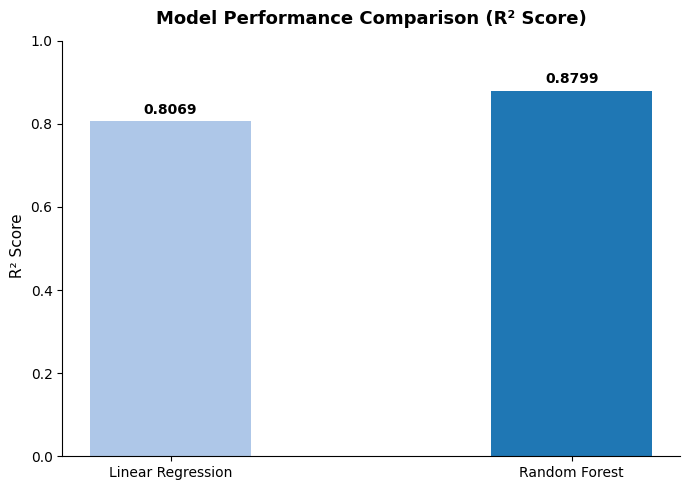

In [27]:
# Chart 3: Model Performance Comparison (R² Score)

models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]  # Lấy từ các biến đã tính ở phần performance_table

plt.figure(figsize=(7, 5))
bars = plt.bar(models, r2_scores, color=['#aec7e8', '#1f77b4'], width=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.title('Model Performance Comparison (R² Score)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel(' R² Score', fontsize=11)
plt.ylim(0, 1.0) # Trục Y chạy từ 0 đến 1 để thấy rõ tỷ lệ phần trăm giải thích được
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

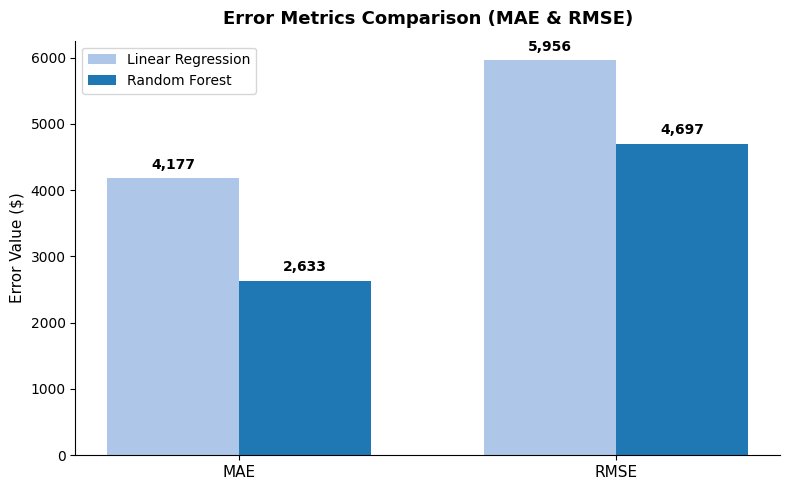

In [28]:
# Error Metrics Comparison (MAE & RMSE)

metrics = ['MAE', 'RMSE']
lr_errors = [lr_mae, lr_rmse]
rf_errors = [rf_mae, rf_rmse]

x_indices = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

# Vẽ cột cho từng mô hình
bar1 = plt.bar(x_indices - width/2, lr_errors, width, label='Linear Regression', color='#aec7e8')
bar2 = plt.bar(x_indices + width/2, rf_errors, width, label='Random Forest', color='#1f77b4')

# Hiển thị số liệu cụ thể trên đầu cột
for bar in bar1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{int(yval):,}', ha='center', va='bottom', fontweight='bold')
for bar in bar2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{int(yval):,}', ha='center', va='bottom', fontweight='bold')

plt.title('Error Metrics Comparison (MAE & RMSE)', fontsize=13, fontweight='bold', pad=12)
plt.xticks(x_indices, metrics, fontsize=11)
plt.ylabel('Error Value ($)', fontsize=11)
plt.legend()
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

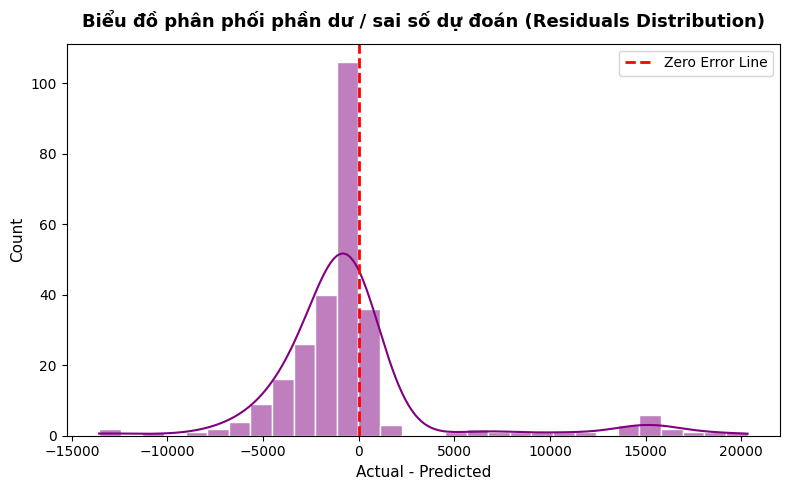

In [30]:
# Residuals Distribution

residuals = y_test - rf_preds

plt.figure(figsize=(8, 5))

# Vẽ biểu đồ mật độ phân phối sai số
sns.histplot(residuals, kde=True, color='purple', bins=30, edgecolor='w')

# Vẽ đường thẳng tại vị trí sai số bằng 0
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error Line')

plt.title('Biểu đồ phân phối phần dư / sai số dự đoán (Residuals Distribution)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual - Predicted', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

Observation:

- Độ chính xác vượt trội: Mô hình Random Forest Regressor giải thích được 87.98% dữ liệu biến động ($R^2 = 0.8798$), cao hơn rõ rệt so với Linear Regression chỉ đạt 80.69%

- Tối ưu hóa sai số: Thuật toán cây giúp cắt giảm mạnh sai số trung bình (MAE) từ $4,177 xuống còn $2,637, chứng minh khả năng dự đoán bám sát thực tế rất tốt của mô hình phi tuyến

- Độ tin cậy cao: Biểu đồ phần dư (Residuals Plot) phân phối tập trung, đối xứng xung quanh vạch 0, khẳng định mô hình không bị lệch xu hướng và có độ ổn định thống kê cao

# 6. CONCLUSION

Kết quả cho thấy Random Forest Regressor là mô hình dự đoán chi phí bảo hiểm hiệu quả nhất, với độ chính xác cao hơn Linear Regression và đạt R² ≈ 0.86. Mô hình khai thác tốt các mối quan hệ phi tuyến giữa các biến, đặc biệt là tuổi, BMI và tình trạng hút thuốc. Điều này khẳng định Machine Learning là công cụ hữu ích trong việc dự báo chi phí bảo hiểm và hỗ trợ ra quyết định trong lĩnh vực bảo hiểm.

# 7. BUSINESS INSIGHTS

a. Insight
- Rủi ro phi tuyến tính: Sự phối hợp giữa thói quen hút thuốc và chỉ số BMI $\ge 30$ (béo phì) tạo ra điểm bùng nổ chi phí cực đại (vượt $40,000). Đây là phân khúc rủi ro kép mà công ty cần siết chặt điều kiện hoặc tăng phí nền để tránh bù lỗ y tế
  
- Yếu tố nhân khẩu học: Giới tính và khu vực sinh sống có đường trung vị phân phối hoàn toàn trùng lặp và không ảnh hưởng đáng kể đến chi phí bảo hiểm thực tế. Định giá bảo hiểm chỉ nên tập trung vào độ tuổi lâm sàng và lối sống y khoa

b. Recommendations:
- Xây dựng mô hình phân tầng rủi ro khách hàng dựa trên tuổi, BMI và tình trạng hút thuốc để hỗ trợ định giá phí bảo hiểm chính xác hơn

- Ưu tiên thẩm định chuyên sâu đối với nhóm khách hàng hút thuốc và có BMI ≥ 30, vì đây là nhóm có mức chi phí bảo hiểm cao nhất và rủi ro bồi thường lớn nhất

- Điều chỉnh mức phí bảo hiểm theo độ tuổi và các chỉ số sức khỏe, do tuổi tác làm chi phí y tế tăng ổn định theo thời gian, trong khi giới tính và khu vực sinh sống có ảnh hưởng không đáng kể

- Triển khai các chương trình chăm sóc sức khỏe như cai thuốc lá, kiểm soát cân nặng và khám sức khỏe định kỳ nhằm giảm rủi ro và tối ưu chi phí bồi thường trong dài hạn

- Ứng dụng mô hình Machine Learning vào quy trình thẩm định và dự báo chi phí bảo hiểm, giúp tự động hóa xét duyệt hồ sơ, nâng cao độ chính xác trong định giá và tối ưu quản lý rủi ro

- Phát triển các gói bảo hiểm cá nhân hóa theo mức độ rủi ro của từng khách hàng, thay vì áp dụng một mức phí chung cho toàn bộ khách hàng